In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [8]:
def sample_image(image, factor):
    height, width = image.shape[:2]
    return cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)

def quantize_image(image, levels):
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    return quantized_image.astype(np.uint8)

def plot_images(original, sampled, quantized):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.imshow(original, cmap='gray'); plt.title('Original Image'); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(sampled, cmap='gray'); plt.title('Sampled Image'); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(quantized, cmap='gray'); plt.title('Quantized Image'); plt.axis('off')
    plt.show()

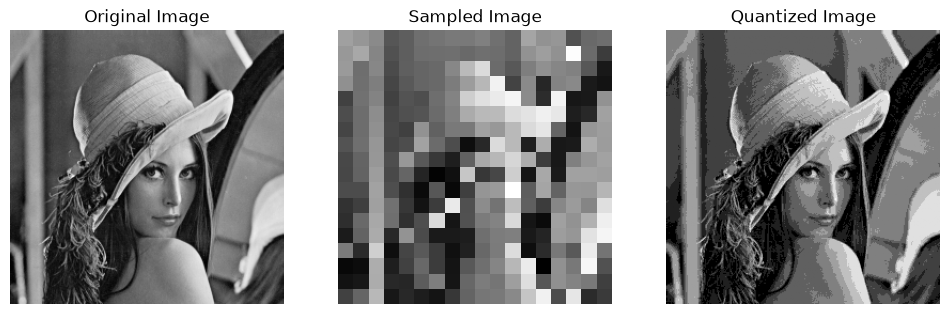

In [9]:
image_path='../images/lena_gray_256.tif'
sampling_factor=14
quantization_levels=9

original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    original_image = np.asarray(Image.open(image_path).convert('L'))

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)
plot_images(original_image, sampled_image, quantized_image)

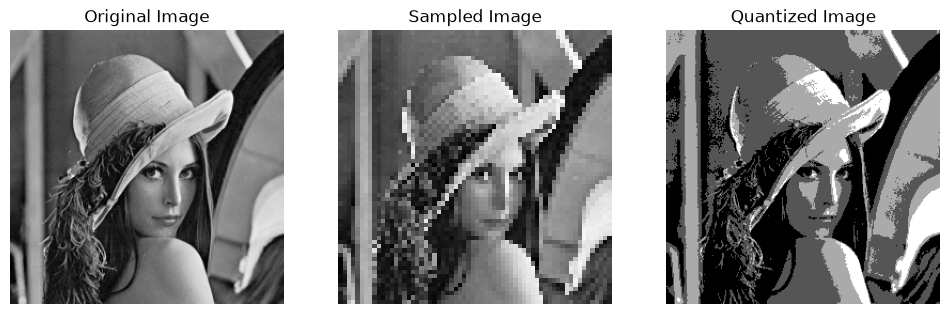

In [10]:
# Changed parameters
sampling_factor=4
quantization_levels=4
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)
plot_images(original_image, sampled_image, quantized_image)

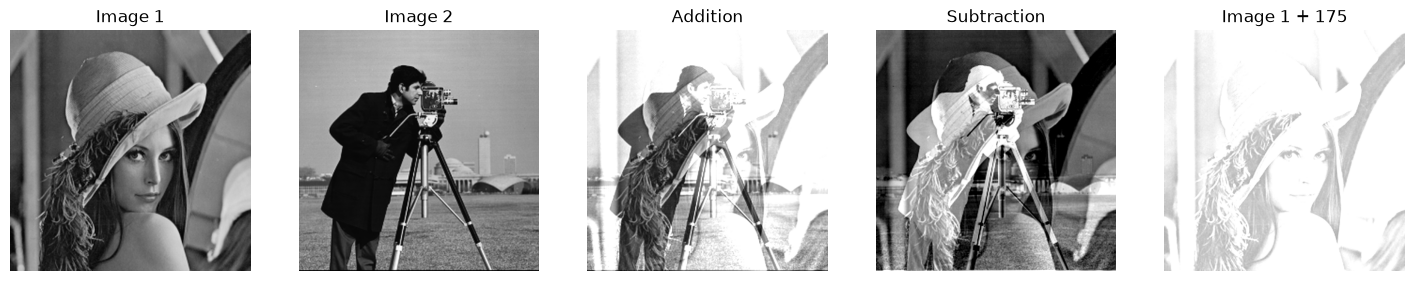

In [11]:
from PIL import Image

img1=Image.open('../images/lena_gray_256.tif')
img2=Image.open('../images/cameraman.tif')
resize=(400,400)
img1=img1.resize(resize,Image.Resampling.LANCZOS)
img2=img2.resize(resize,Image.Resampling.LANCZOS)
im1arr=np.asarray(img1).astype(np.int16)
im2arr=np.asarray(img2).astype(np.int16)

addition=np.clip(im1arr+im2arr,0,255).astype(np.uint8)
subtraction=im1arr-im2arr
subtraction_display=np.clip(subtraction+128,0,255).astype(np.uint8)
constant_addition=np.clip(im1arr+175,0,255).astype(np.uint8)

fig, ax = plt.subplots(1, 5, figsize=(18, 4))
results=[im1arr, im2arr, addition, subtraction_display, constant_addition]
titles=['Image 1','Image 2','Addition','Subtraction','Image 1 + 175']
for a, result, title in zip(ax, results, titles):
    a.imshow(result, cmap='gray', vmin=0, vmax=255)
    a.set_title(title)
    a.axis('off')
plt.show()

resultImage=Image.fromarray(addition)
resultImage.show()

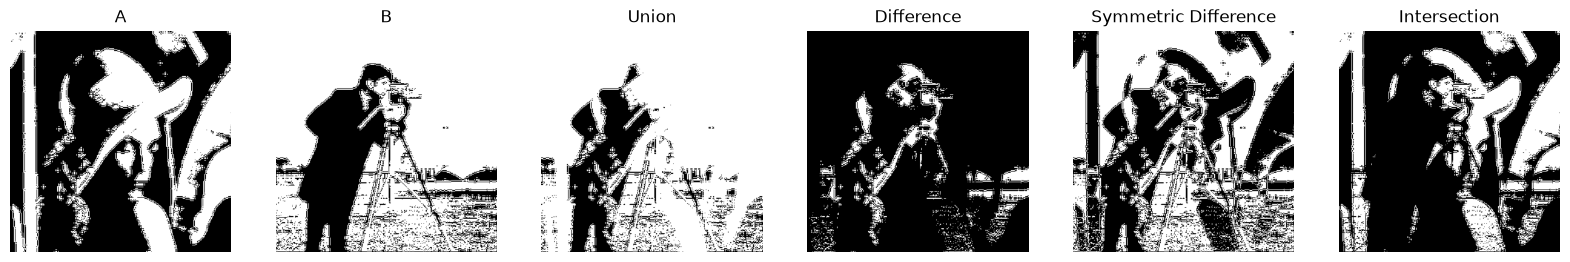

In [12]:
img3=Image.open('../images/A.png')
img3.show()
img4=Image.open('../images/B.png')
img4.show()
resize=(400,400)
img3=img3.resize(resize,Image.Resampling.LANCZOS)
img4=img4.resize(resize,Image.Resampling.LANCZOS)
im3arr=np.asarray(img3) > 0
im4arr=np.asarray(img4) > 0

union=(im4arr | im3arr).astype(np.uint8)*255
difference=(im3arr & ~im4arr).astype(np.uint8)*255
symmetric_difference=(im3arr ^ im4arr).astype(np.uint8)*255
intersection=(im3arr & im4arr).astype(np.uint8)*255

fig, ax = plt.subplots(1, 6, figsize=(20, 4))
results=[im3arr, im4arr, union, difference, symmetric_difference, intersection]
titles=['A','B','Union','Difference','Symmetric Difference','Intersection']
for a, result, title in zip(ax, results, titles):
    a.imshow(result, cmap='gray', vmin=0, vmax=1 if result.dtype == bool else 255)
    a.set_title(title)
    a.axis('off')
plt.show()

resultImage2=Image.fromarray(union)
resultImage2.show()